# Chirp

In [ ]:
import os
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path

In [ ]:
import sys

sys.path.append(str(Path('../..').parent))

from utils import plot_stim

In [ ]:
import yaml

with open('../../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

In [ ]:
qdspy_export_dir = Path(config["qdspy"]["export_dir"])
os.listdir(qdspy_export_dir)

['RGC_Chirp_1000um_60Hz_10um_pixels.npz',
 'RGC_Chirp_1000um_60Hz_10um_pixels_mark.npz',
 'RGC_Chirp_800um_60Hz_10um_pixels.npz',
 'RGC_Chirp_800um_60Hz_10um_pixels_mark.npz',
 'v2']

In [ ]:
out_dir = Path(config["output_dir"])
os.makedirs(out_dir, exist_ok=True)

In [ ]:
pixel_size_um = 10

crop_setup1_h = config["qdspy"]["crop"]["setup1"]["h"]
crop_setup1_v = config["qdspy"]["crop"]["setup1"]["v"]

crop_setup3_h = config["qdspy"]["crop"]["setup3"]["h"]
crop_setup3_v = config["qdspy"]["crop"]["setup3"]["v"]

In [ ]:
chirp800_file = 'RGC_Chirp_800um_60Hz_10um_pixels.npz'
chirp800_mark_file = 'RGC_Chirp_800um_60Hz_10um_pixels_mark.npz'

chirp1000_file = 'RGC_Chirp_1000um_60Hz_10um_pixels.npz'
chirp1000_mark_file = 'RGC_Chirp_1000um_60Hz_10um_pixels_mark.npz'

In [ ]:
chirp800 = np.load(os.path.join(qdspy_export_dir, chirp800_file))['data']
chirp800 = np.round(np.mean(chirp800, axis=-1)).astype(int)
chirp800.shape

(1980, 120, 120)

In [ ]:
chirp1000 = np.load(os.path.join(qdspy_export_dir, chirp1000_file))['data']
chirp1000 = np.round(np.mean(chirp1000, axis=-1)).astype(int)
chirp1000.shape

(1980, 120, 120)

In [ ]:
chirp_mark = np.load(os.path.join(qdspy_export_dir, chirp800_mark_file))['data']
chirp_mark = np.append(chirp_mark[:-1] & (~chirp_mark[1:]), False)
chirp_mark

array([False, False,  True, ..., False, False, False], shape=(1980,))

In [ ]:
time_chirp = np.arange(chirp800.shape[0]) * 1./60.

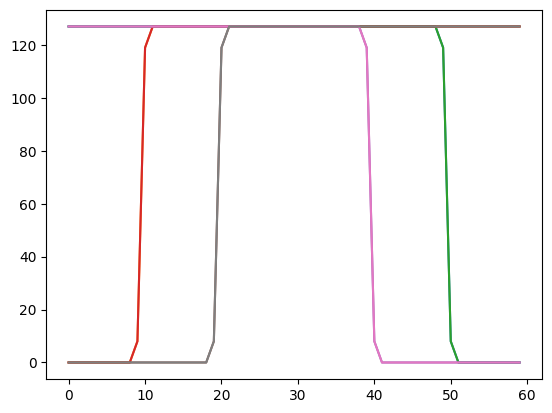

In [ ]:
# Checking that the chirp is centered correctly

t_s = 10
x_center = chirp1000.shape[1]//2
y_center = chirp1000.shape[2]//2

plt.plot(chirp1000[int(60*t_s), :x_center, y_center][::-1])
plt.plot(chirp1000[int(60*t_s), :x_center, y_center])
plt.plot(chirp1000[int(60*t_s), x_center, :y_center][::-1])
plt.plot(chirp1000[int(60*t_s), x_center, :y_center])

plt.plot(chirp800[int(60*t_s), :x_center, y_center][::-1])
plt.plot(chirp800[int(60*t_s), :x_center, y_center])
plt.plot(chirp800[int(60*t_s), x_center, :y_center][::-1])
plt.plot(chirp800[int(60*t_s), x_center, :y_center])

plt.show()

In [ ]:
stim_dict =  {
    ('chirp1000', '1'): chirp1000,
    ('chirp800', '1'): chirp800,
}

Plotting chirp1000


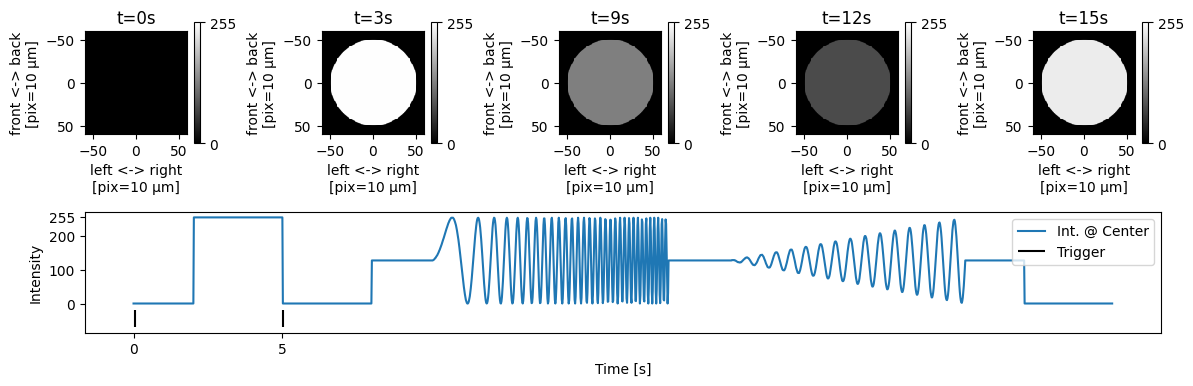

Plotting chirp800


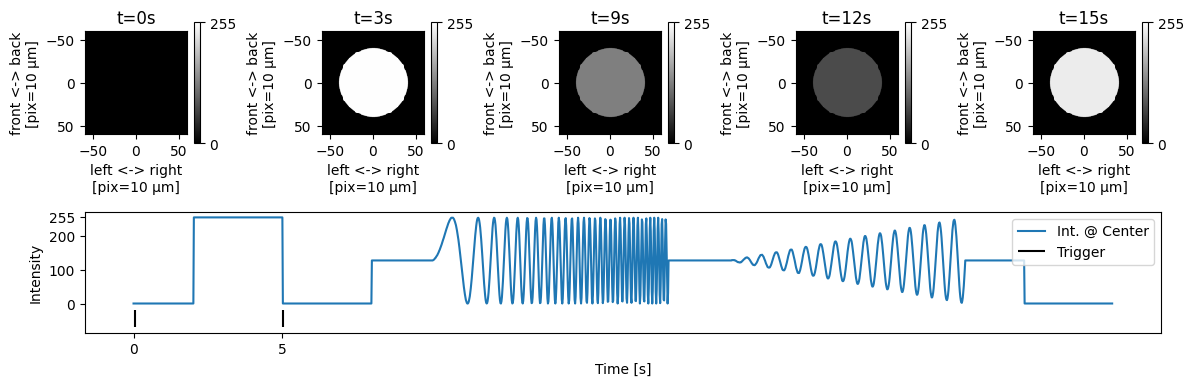

In [ ]:
t_s_plot = [0, 3, 9, 12, 15]

for (name, setup), stim in stim_dict.items():
    print(f'Plotting {name}')
    fig, axs = plot_stim(stim, chirp_mark, time_chirp, t_s_plot=t_s_plot);
    plt.savefig(os.path.join(out_dir, f'{name}.pdf'), bbox_inches='tight')
    plt.show()

In [ ]:
# No rotation / flips necessary as stimulus is point-symmetric. Just cropping to the same size as the other stimuli.
chirp800_setup1 = np.flip(chirp800, axis=1)[:, crop_setup1_v:-crop_setup1_v, crop_setup1_h:-crop_setup1_h]
chirp1000_setup1 = np.flip(chirp1000, axis=1)[:, crop_setup1_v:-crop_setup1_v, crop_setup1_h:-crop_setup1_h]

chirp800_setup3 = chirp800[:, crop_setup3_v:-crop_setup3_v, crop_setup3_h:-crop_setup3_h]
chirp1000_setup3 = chirp1000[:, crop_setup3_v:-crop_setup3_v, crop_setup3_h:-crop_setup3_h]

In [ ]:
stim_dict = {
    ('chirp800', '1'): chirp800_setup1,
    ('chirp1000', '1'): chirp1000_setup1,
    #('chirp800', '3'): chirp800_setup3,  # Same on both setups
    #('chirp1000', '3'): chirp1000_setup3,
}

Plotting chirp800


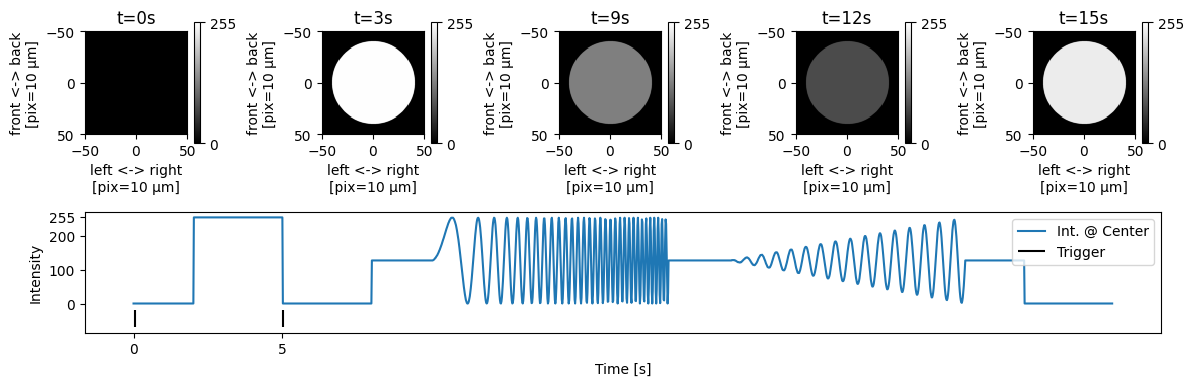

Plotting chirp1000


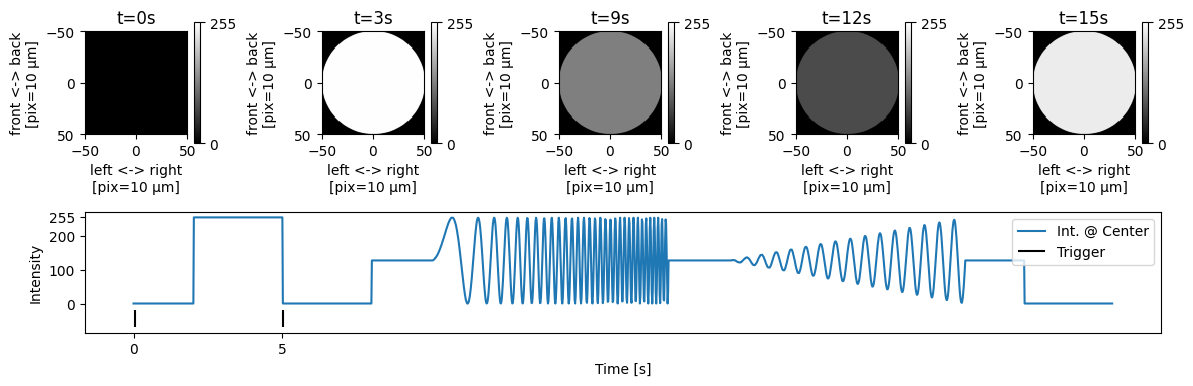

In [ ]:
for (name, setup), stim in stim_dict.items():
    print(f'Plotting {name}')
    
    fig, axs = plot_stim(stim, chirp_mark, time_chirp, t_s_plot=t_s_plot)
    plt.savefig(os.path.join(out_dir, f'{name}.pdf'), bbox_inches='tight')
    plt.show()

In [ ]:
# Test is stimulus is the same for both setups
# assert np.all(chirp1000_setup1 == chirp1000_setup3), This test actually fails because of minor asymmetries in the stimulus export
# assert np.all(chirp800_setup1 == chirp800_setup3), This test actually fails because of minor asymmetries in the stimulus export

target_freq = 60
assert np.isclose(target_freq, np.round(1 / np.mean(np.diff(time_chirp))))

for (name, setup), stim in stim_dict.items():
    
    assert np.all(stim.astype(np.uint8) == stim)
    np.savez_compressed(
        os.path.join(out_dir, f'{name}_movie_and_trigger'),
        stimulus=stim.astype(np.uint8),
        time=time_chirp.astype(np.float32),
        framerate=target_freq,
        trigger=chirp_mark,
        pixel_size_um=pixel_size_um,
    )